# Семинар 3. Сверточные нейронные сети.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from time import perf_counter
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm

warnings.filterwarnings('ignore')

plt.rc('font', size=30)

## Работа с изображениями

In [2]:
! wget "https://static.wikia.nocookie.net/the-curse-of-the-wise-tree/images/e/e4/Mudroe-tainstvennoe-derevo-mem-25.jpg/revision/latest?cb=20230102165328&path-prefix=ru" -O tree.jpg

--2025-11-03 13:58:57--  https://static.wikia.nocookie.net/the-curse-of-the-wise-tree/images/e/e4/Mudroe-tainstvennoe-derevo-mem-25.jpg/revision/latest?cb=20230102165328&path-prefix=ru
Resolving static.wikia.nocookie.net (static.wikia.nocookie.net)... 74.120.190.204, 74.120.190.194
Connecting to static.wikia.nocookie.net (static.wikia.nocookie.net)|74.120.190.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 130525 (127K) [image/jpeg]
Saving to: ‘tree.jpg’

tree.jpg            100%[===================>] 127.47K   246KB/s    in 0.5s    

2025-11-03 13:58:59 (246 KB/s) - ‘tree.jpg’ saved [130525/130525]



In [3]:
img = Image.open('tree.jpg')

type(img)

PIL.JpegImagePlugin.JpegImageFile

In [4]:
img.format, img.size, img.mode

('JPEG', (799, 800), 'RGB')

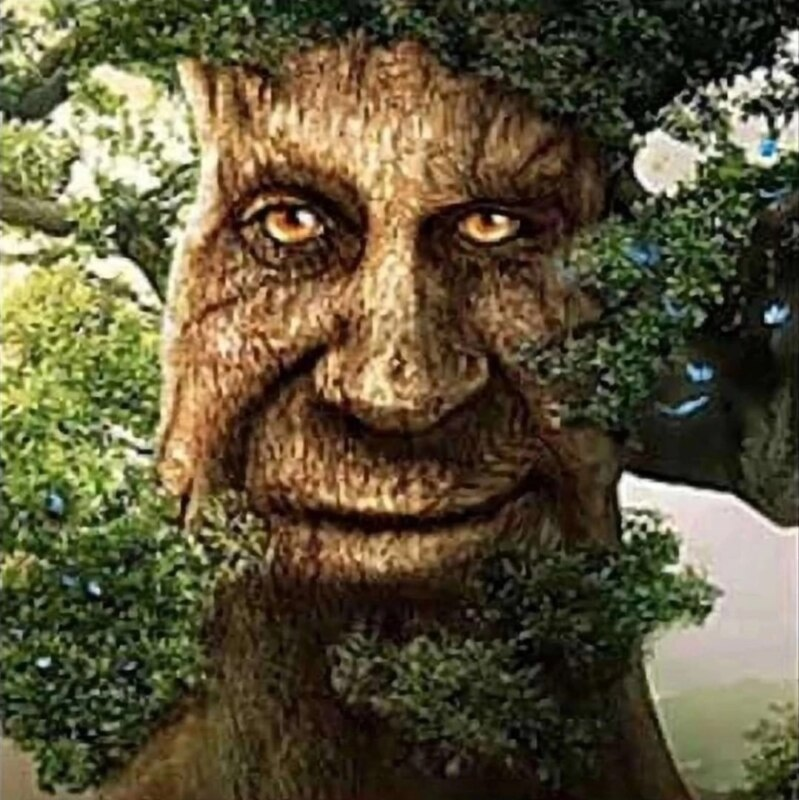

In [5]:
img

PIL.Image можем преобразовать в numpy массив в формате (H, W, C)

In [6]:
img_array = np.array(img)
img_array.shape, img_array.dtype, img_array.min(), img_array.max()

((800, 799, 3), dtype('uint8'), 0, 255)

Чтобы преобразовать изображение в торчевый тензор, можно воспользоваться трансформом ToTensor из torchvision.transforms.v2

`Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]`

In [7]:
img_tensor = T.ToTensor()(img)
img_tensor.shape, img_tensor.dtype, img_tensor.min(), img_tensor.max()

(torch.Size([3, 800, 799]), torch.float32, tensor(0.), tensor(1.))

В новых версиях торча рекомендуется использовать следующий трансформ, так как ToTensor() считается deprecated.

In [8]:
img_to_tensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
img_tensor = img_to_tensor(img)
img_tensor.shape, img_tensor.dtype, img_tensor.min(), img_tensor.max()

(torch.Size([3, 800, 799]), torch.float32, tensor(0.), tensor(1.))

Визуализировать numpy массив можно с помощью plt.imshow

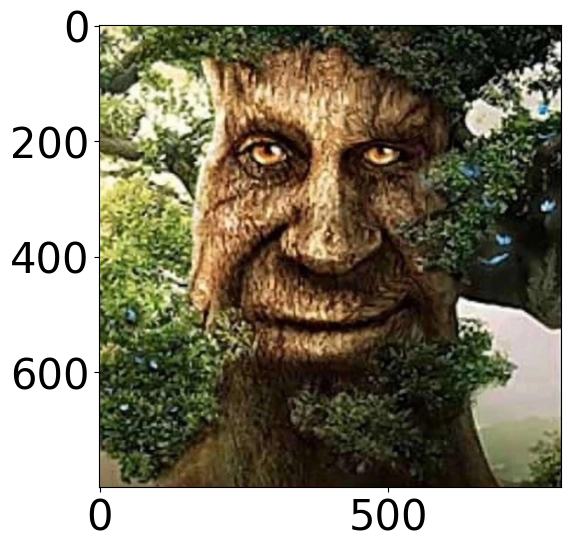

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(img_array)
plt.show()

В торче формат изображений обычно (C, H, W). Однако, для визуализации с помощью matplotlib нам нужно, чтобы каналы шли последними, то есть (H, W, C).

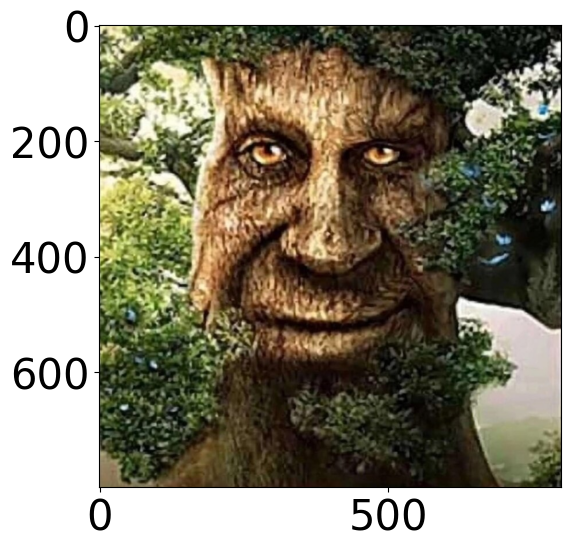

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(img_tensor.permute((1, 2, 0)))
plt.show()

## Свертка

Свертка в PyTorch представлена модулем nn.Conv2d со следующими параметрами:

- in_channels (int) – Количество каналов во входном изображении

- out_channels (int) – Количество каналов в выходном изображении

- kernel_size (int or tuple) – Размер ядра свертки

- stride (int or tuple, optional) – Страйд (шаг ядра свертки). По умолчанию: 1

- padding (int, tuple or str, optional) – Размер паддинга. По умолчанию: 0

- padding_mode (string, optional) – 'zeros', 'reflect', 'replicate' or 'circular'. По умолчанию: 'zeros'

- dilation (int or tuple, optional) – Дилейшн (шаг между элементами внутри ядра). По умолчанию: 1

- bias (bool, optional) – добавлять ли обучаемый сдвиг. По умолчанию: True

Свертка без паддинга с единичным страйдом

In [11]:
import IPython.display
IPython.display.Image(url='https://maucher.home.hdm-stuttgart.de/Pics/gif/no_padding_no_strides.gif')

Выставим паддинг в 1

In [12]:
IPython.display.Image(url='https://maucher.home.hdm-stuttgart.de/Pics/gif/same_padding_no_strides.gif')

Выставим страйд 2 без паддинга

In [13]:
IPython.display.Image(url='https://maucher.home.hdm-stuttgart.de/Pics/gif/no_padding_strides.gif')

Визуализация двумерной свертки с разными параметрами

https://ezyang.github.io/convolution-visualizer/

https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html

In the simplest case, the output value of the layer with input size
$(N, C_{\text{in}}, H, W)$ and output $(N, C_{\text{out}}, H_{\text{out}}, W_{\text{out}})$
can be precisely described as:

$$
    \text{out}(N_i, C_{\text{out}_j}) = \text{bias}(C_{\text{out}_j}) +
    \sum_{k = 0}^{C_{\text{in}} - 1} \text{weight}(C_{\text{out}_j}, k) \star \text{input}(N_i, k)
$$

where $\star$ is the valid 2D convolution,
$N$ is a batch size, $C$ denotes a number of channels,
$H$ is a height of input planes in pixels, and $W$ is
width in pixels.


То есть для каждого выходного канала мы сворачиваем каждый входной канал картинки с соответствующим ядром для этого входного канала и потом складываем эти C_in "разверток".

In [14]:
conv = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3
)
# по умолчанию padding=0, stride=1

Ядро свертки - это in_channels * out_channels окошек kernel_size * kernel_size

In [15]:
conv.weight.shape, conv.bias.shape

(torch.Size([10, 3, 3, 3]), torch.Size([10]))

In [16]:
img_tensor.shape

torch.Size([3, 800, 799])

In [17]:
output = conv(img_tensor)

output.shape

torch.Size([10, 798, 797])

### Пересчет размера изображения после свертки

- Input: $(N, C_{in}, H_{in}, W_{in})$ or $(C_{in}, H_{in}, W_{in})$
- Output: $(N, C_{out}, H_{out}, W_{out})$ or $(C_{out}, H_{out}, W_{out})$, where

$$
        H_{out} = \left\lfloor\frac{H_{in}  + 2 \times \text{padding}[0] - \text{dilation}[0]
                \times (\text{kernel\_size}[0] - 1) - 1}{\text{stride}[0]} + 1\right\rfloor
$$

$$
    
        W_{out} = \left\lfloor\frac{W_{in}  + 2 \times \text{padding}[1] - \text{dilation}[1]
                \times (\text{kernel\_size}[1] - 1) - 1}{\text{stride}[1]} + 1\right\rfloor
$$

Поймем почему так пересчитываются новые размеры картинок. Сначала для простоты положим stride=1, dilation=1, padding=0.

Сколько раз мы можем приложить окошко размера kernel_size*kernel_size к (H_in, W_in)? Одна стартовая позиция в левом верхнем углу допустим у нас уже есть. Для ширины например понятно, что еще есть W_in - kernel_size позиций.

In [18]:
IPython.display.Image(url='seminar_03_media/conv_base.png', width=200)

In [19]:
H, W = 6, 6
kernel_size = 3
conv = nn.Conv2d(
    in_channels=3,
    out_channels=3,
    kernel_size=kernel_size
)
x = torch.ones((1, 3, H, W))
y = conv(x)

print("output image size:", y.shape[2:])
print("new width:", 1 + W - kernel_size)

output image size: torch.Size([4, 4])
new width: 4


Выставляем padding и у нас появляется дополнительно 2 * padding позиций (слева и справа для ширины например), чтобы приложить окошко

In [20]:
IPython.display.Image(url='seminar_03_media/conv_padding.png', width=200)

In [21]:
padding = 1
conv.padding = padding
y = conv(x)

print("output image size:", y.shape[2:])
print("new width:", 1 + W - kernel_size + 2 * padding)

output image size: torch.Size([6, 6])
new width: 6


Теперь добавим dilation. Мы добавляем "дырки" размера dilation - 1 между соседними пикселями в окошке. То есть размер нового окна kernel_size + (dilation - 1) * (kernel_size - 1) = dilation * (kernel_size - 1) + 1

In [22]:
IPython.display.Image(url='seminar_03_media/conv_dilation.png', width=200)

In [23]:
dilation = 2
conv.dilation = dilation
y = conv(x)

print("output image size:", y.shape[2:])
print("new width:", 1 + W - (dilation * (kernel_size - 1) + 1) + 2 * padding)

output image size: torch.Size([4, 4])
new width: 4


Наконец добавим stride. Тут нужно просто число свободных позиций поделить на шаг ядра (stride).

In [24]:
stride = 2
conv.stride = stride
y = conv(x)

print("output image size:", y.shape[2:])
print("new width:", 1 + (W - (dilation * (kernel_size - 1) + 1) + 2 * padding) // stride)

output image size: torch.Size([2, 2])
new width: 2


### Фиксированные ядра сверток

In [25]:
kernel_size = 20
kernel = torch.ones((kernel_size, kernel_size), dtype=torch.float32)
kernel = kernel / kernel.sum()

kernel = kernel.view(1, 1, kernel_size, kernel_size).expand(3, 1, -1, -1)

conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=kernel_size, padding="same", bias=False, groups=3)
with torch.no_grad():
    conv.weight.data = kernel
    conv.weight.requires_grad = False  # Замораживаем градиенты


output = conv(img_tensor.unsqueeze(0)).squeeze(0)

img_tensor.shape, output.shape

(torch.Size([3, 800, 799]), torch.Size([3, 800, 799]))

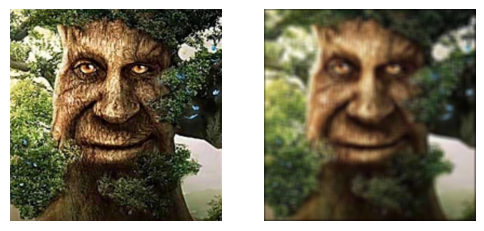

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(6,4))
axes[0].imshow(img_tensor.permute(1,2,0).numpy())
axes[1].imshow(output.permute(1,2,0).numpy())
for ax in axes:
    ax.set_axis_off()

## Pooling

Пулинг представлен в модуле torch.nn, в основном будем использовать MaxPool2d и AvgPool2d.

Параметры:

- kernel_size – размер окошка

- stride – страйд окошка. По умолчанию равен kernel_size

- padding – сколько нулевого паддинга добавлять по краям. По умолчанию: 0.

In [27]:
tensor = torch.randint(0, 5, size=(6, 6), dtype=torch.float32).unsqueeze(0)

In [28]:
tensor

tensor([[[3., 4., 1., 3., 4., 3.],
         [1., 2., 4., 3., 3., 3.],
         [2., 0., 2., 1., 2., 2.],
         [1., 1., 0., 0., 4., 1.],
         [4., 4., 3., 4., 3., 3.],
         [4., 3., 0., 3., 2., 2.]]])

In [29]:
pooling1 = nn.MaxPool2d(kernel_size=2)

In [30]:
pooling1(tensor)

tensor([[[4., 4., 4.],
         [2., 2., 4.],
         [4., 4., 3.]]])

In [31]:
pooling2 = nn.AvgPool2d(kernel_size=2)

In [32]:
pooling2(tensor)

tensor([[[2.5000, 2.7500, 3.2500],
         [1.0000, 0.7500, 2.2500],
         [3.7500, 2.5000, 2.5000]]])

## Feed Forward vs Convolution Network on MNIST

In [33]:
mnist_train = MNIST(
    "datasets/mnist",
    train=True,
    download=True,
    transform=img_to_tensor
)
mnist_valid = MNIST(
    "datasets/mnist",
    train=False,
    download=True,
    transform=img_to_tensor
)

In [34]:
len(mnist_train), len(mnist_valid)

(60000, 10000)

In [35]:
mnist_train[0][0].shape, mnist_train[0][1]

(torch.Size([1, 28, 28]), 5)

In [36]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True, num_workers=2)
valid_loader = DataLoader(mnist_valid, batch_size=64, shuffle=False, num_workers=2)

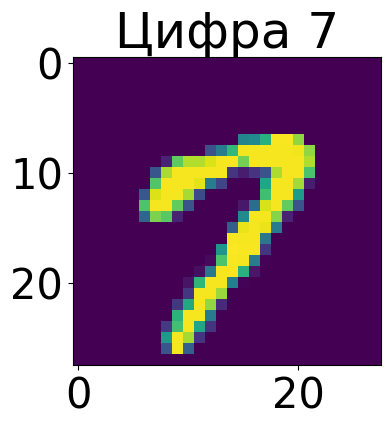

In [37]:
plt.figure(figsize=(4, 4))
plt.title(f'Цифра {mnist_train[15][1]}')
plt.imshow(mnist_train[15][0][0])

plt.show()

Обучим полносвязную нейронную сеть на датасете MNIST.

In [38]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        output = model(x)
        loss = loss_fn(output, y)
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [39]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        with torch.no_grad():
            output = model(x)
            loss = loss_fn(output, y)

        total_loss += loss.item()
        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [41]:
from IPython.display import clear_output


def fit(model, train_loader, valid_loader, optimizer, loss_fn, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

In [42]:
mlp_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

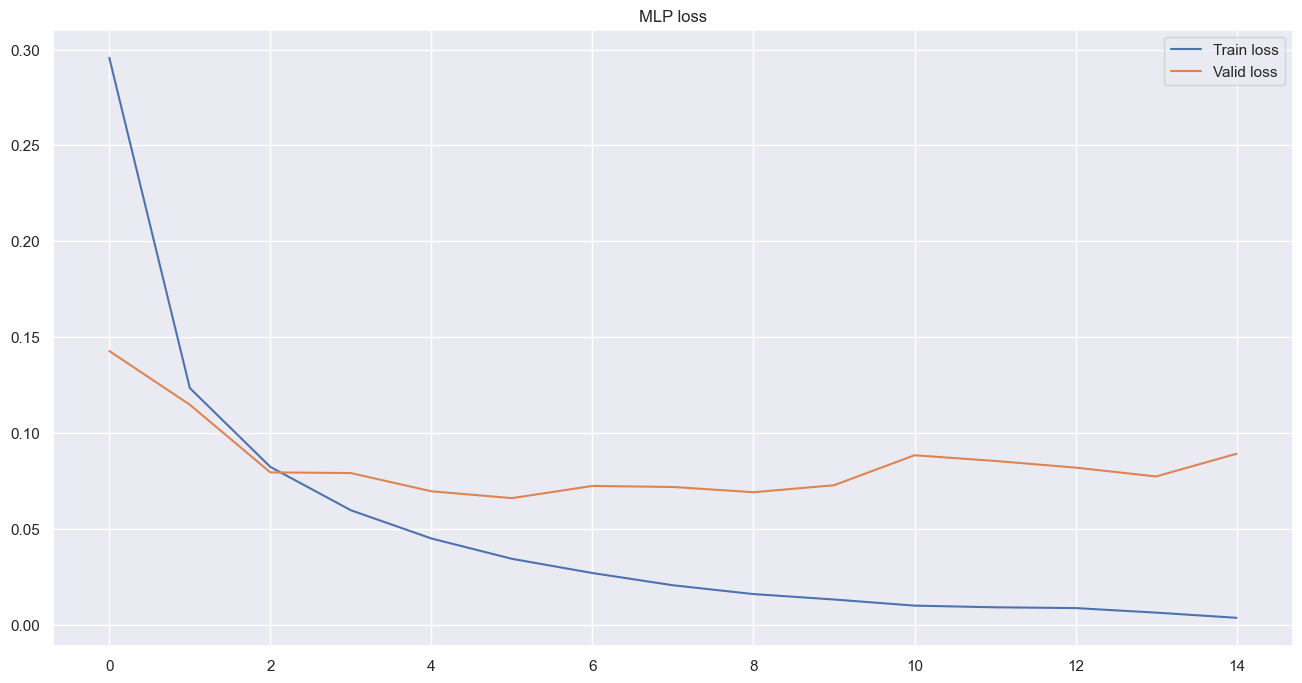

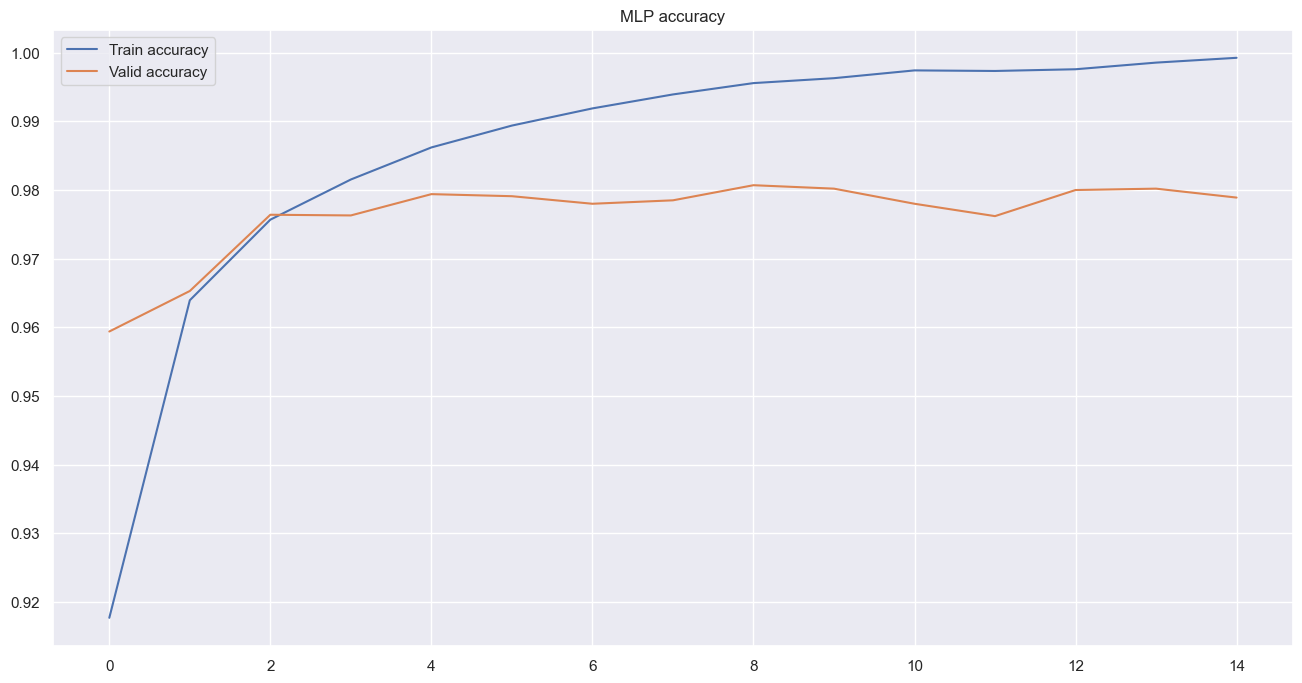

In [43]:
fit(mlp_model, train_loader, valid_loader, optimizer, loss_fn, 15, 'MLP')

Теперь давайте обучим сверточную сеть.

In [44]:
conv_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),  # 28 x 28 -> 24 x 24
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 24 x 24 -> 12 x 12

    nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),  # 12 x 12 -> 8 x 8
    nn.LeakyReLU(),
    nn.MaxPool2d(kernel_size=2),  # 8 x 8 -> 4 x 4

    nn.Flatten(),  # 4 x 4 x 16 -> 4 * 4 * 16
    nn.Linear(4 * 4 * 16, 100),
    nn.LeakyReLU(),
    nn.Linear(100, 10)
)

optimizer = torch.optim.Adam(conv_model.parameters(), lr=1e-3)

loss_fn = nn.CrossEntropyLoss()

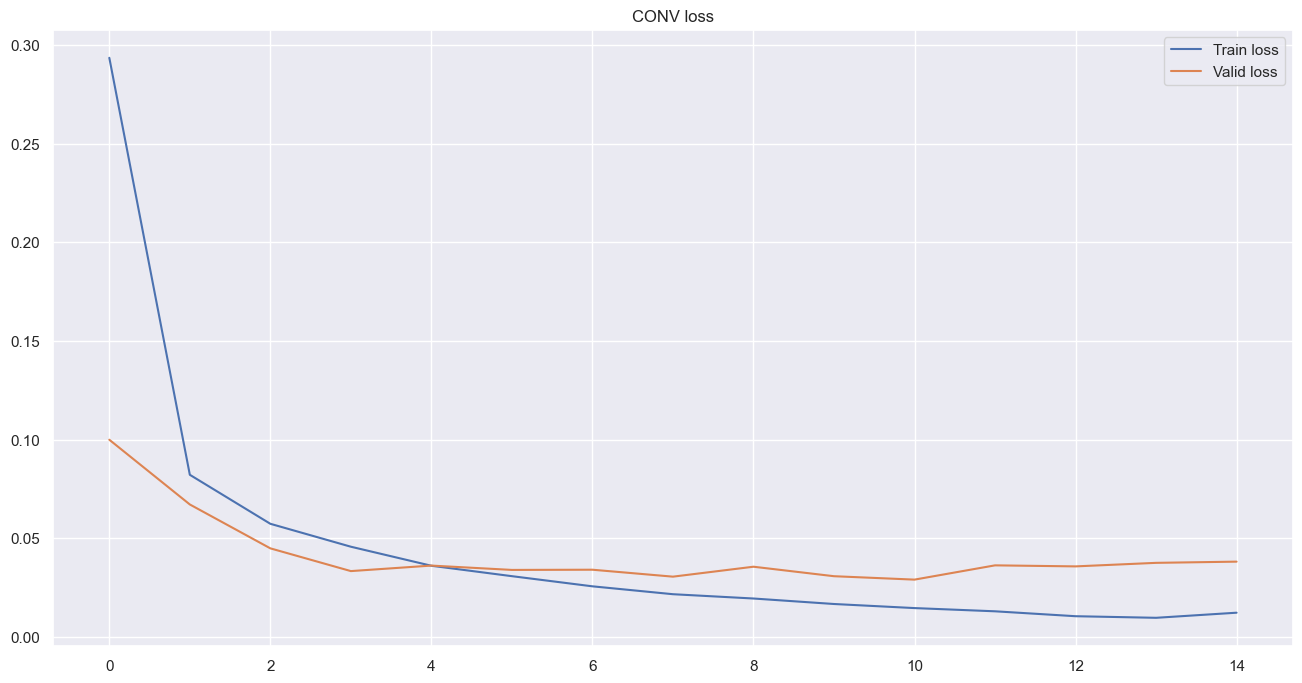

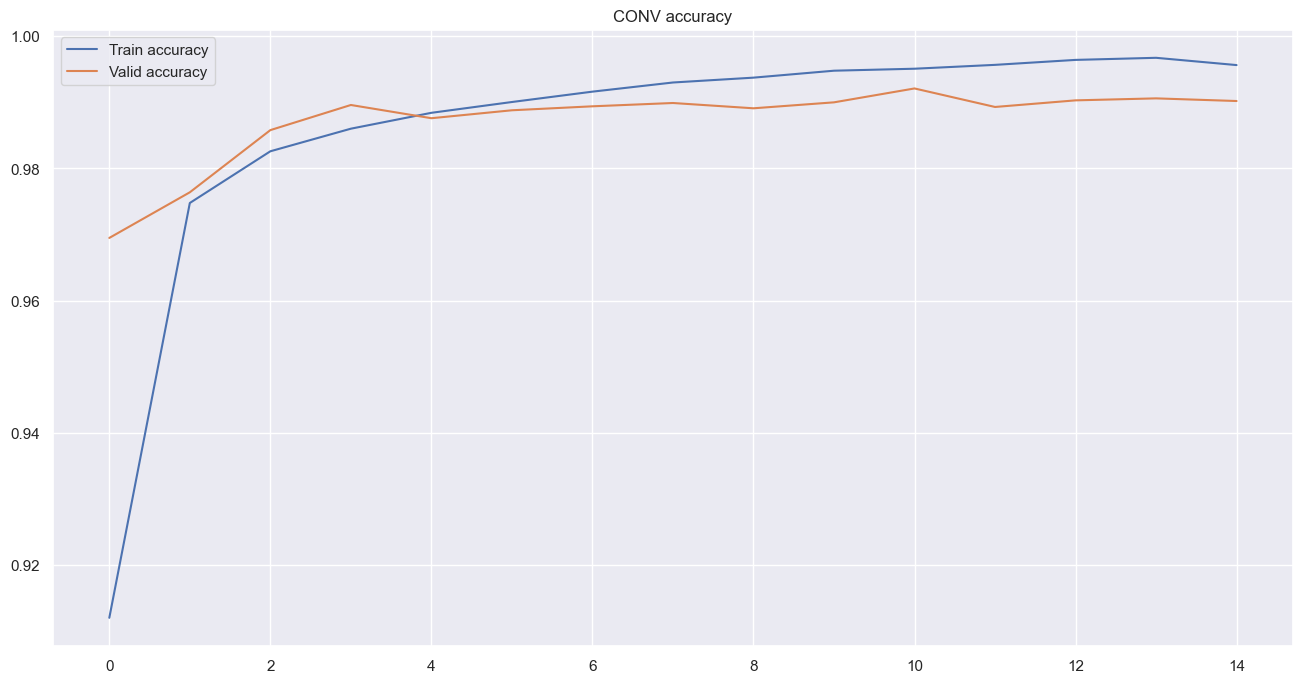

In [45]:
fit(conv_model, train_loader, valid_loader, optimizer, loss_fn, 15, 'CONV')